## 警告信息配置说明

为了保持输出整洁，本notebook已配置以下设置来抑制LightGBM和其他库的警告信息：

- **LightGBM verbosity设置**: 所有LightGBM模型的`verbosity`参数设置为`-1`，完全抑制日志输出
- **Python warnings抑制**: 使用`warnings.filterwarnings('ignore')`抑制Python警告
- **环境变量设置**: 通过`os.environ['PYTHONWARNINGS'] = 'ignore'`抑制系统级警告

这些设置确保了训练过程的输出更加简洁和清晰。

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # 导入Seaborn库，用于统计数据可视化
plt.rcParams['font.sans-serif'] = ['SimHei']
import xgboost as xgb
import lightgbm as lgb 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# 抑制LightGBM和其他库的警告信息
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

# 添加CatBoost用于GPU加速
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("✅ CatBoost已导入，支持GPU加速")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠️ CatBoost未安装，跳过CatBoost相关功能")

✅ CatBoost已导入，支持GPU加速


### GPU环境检测

In [50]:
def check_gpu_environment():
    """检测GPU环境和各库的GPU支持情况"""
    print("🔍 GPU环境检测开始...")
    
    # 检测CUDA
    try:
        import torch
        cuda_available = torch.cuda.is_available()
        if cuda_available:
            gpu_count = torch.cuda.device_count()
            gpu_name = torch.cuda.get_device_name(0)
            print(f"✅ CUDA可用: {cuda_available}")
            print(f"   GPU数量: {gpu_count}")
            print(f"   GPU型号: {gpu_name}")
        else:
            print("❌ CUDA不可用")
    except ImportError:
        print("❌ PyTorch未安装，无法检测CUDA")
        cuda_available = False
    
    # 检测XGBoost GPU支持
    try:
        import xgboost as xgb
        print(f"✅ XGBoost版本: {xgb.__version__}")
        # 测试GPU可用性
        try:
            xgb_gpu_test = xgb.XGBClassifier(tree_method='gpu_hist', gpu_id=0, n_estimators=1)
            print("   XGBoost GPU支持: ✅")
        except Exception as e:
            print(f"   XGBoost GPU支持: ❌ ({str(e)[:50]})")
    except ImportError:
        print("❌ XGBoost未安装")
    
    # 检测LightGBM GPU支持
    try:
        import lightgbm as lgb
        print(f"✅ LightGBM版本: {lgb.__version__}")
        print("   LightGBM GPU支持: 需要编译时启用GPU")
    except ImportError:
        print("❌ LightGBM未安装")
    
    # 检测CatBoost GPU支持
    try:
        from catboost import CatBoostClassifier
        print(f"✅ CatBoost已安装")
        print("   CatBoost GPU支持: ✅ (默认支持)")
    except ImportError:
        print("❌ CatBoost未安装")
    
    print("🔍 GPU环境检测完成")
    return cuda_available

# 执行GPU环境检测
gpu_available = check_gpu_environment()

🔍 GPU环境检测开始...
✅ CUDA可用: True
   GPU数量: 1
   GPU型号: NVIDIA GeForce RTX 3060 Laptop GPU
✅ XGBoost版本: 3.0.4
   XGBoost GPU支持: ✅
✅ LightGBM版本: 4.6.0
   LightGBM GPU支持: 需要编译时启用GPU
✅ CatBoost已安装
   CatBoost GPU支持: ✅ (默认支持)
🔍 GPU环境检测完成


## 一、数据探索

### 1. 数据加载

In [51]:
train_data = pd.read_csv('health/health_lifestyle_classification.csv',encoding='utf-8')

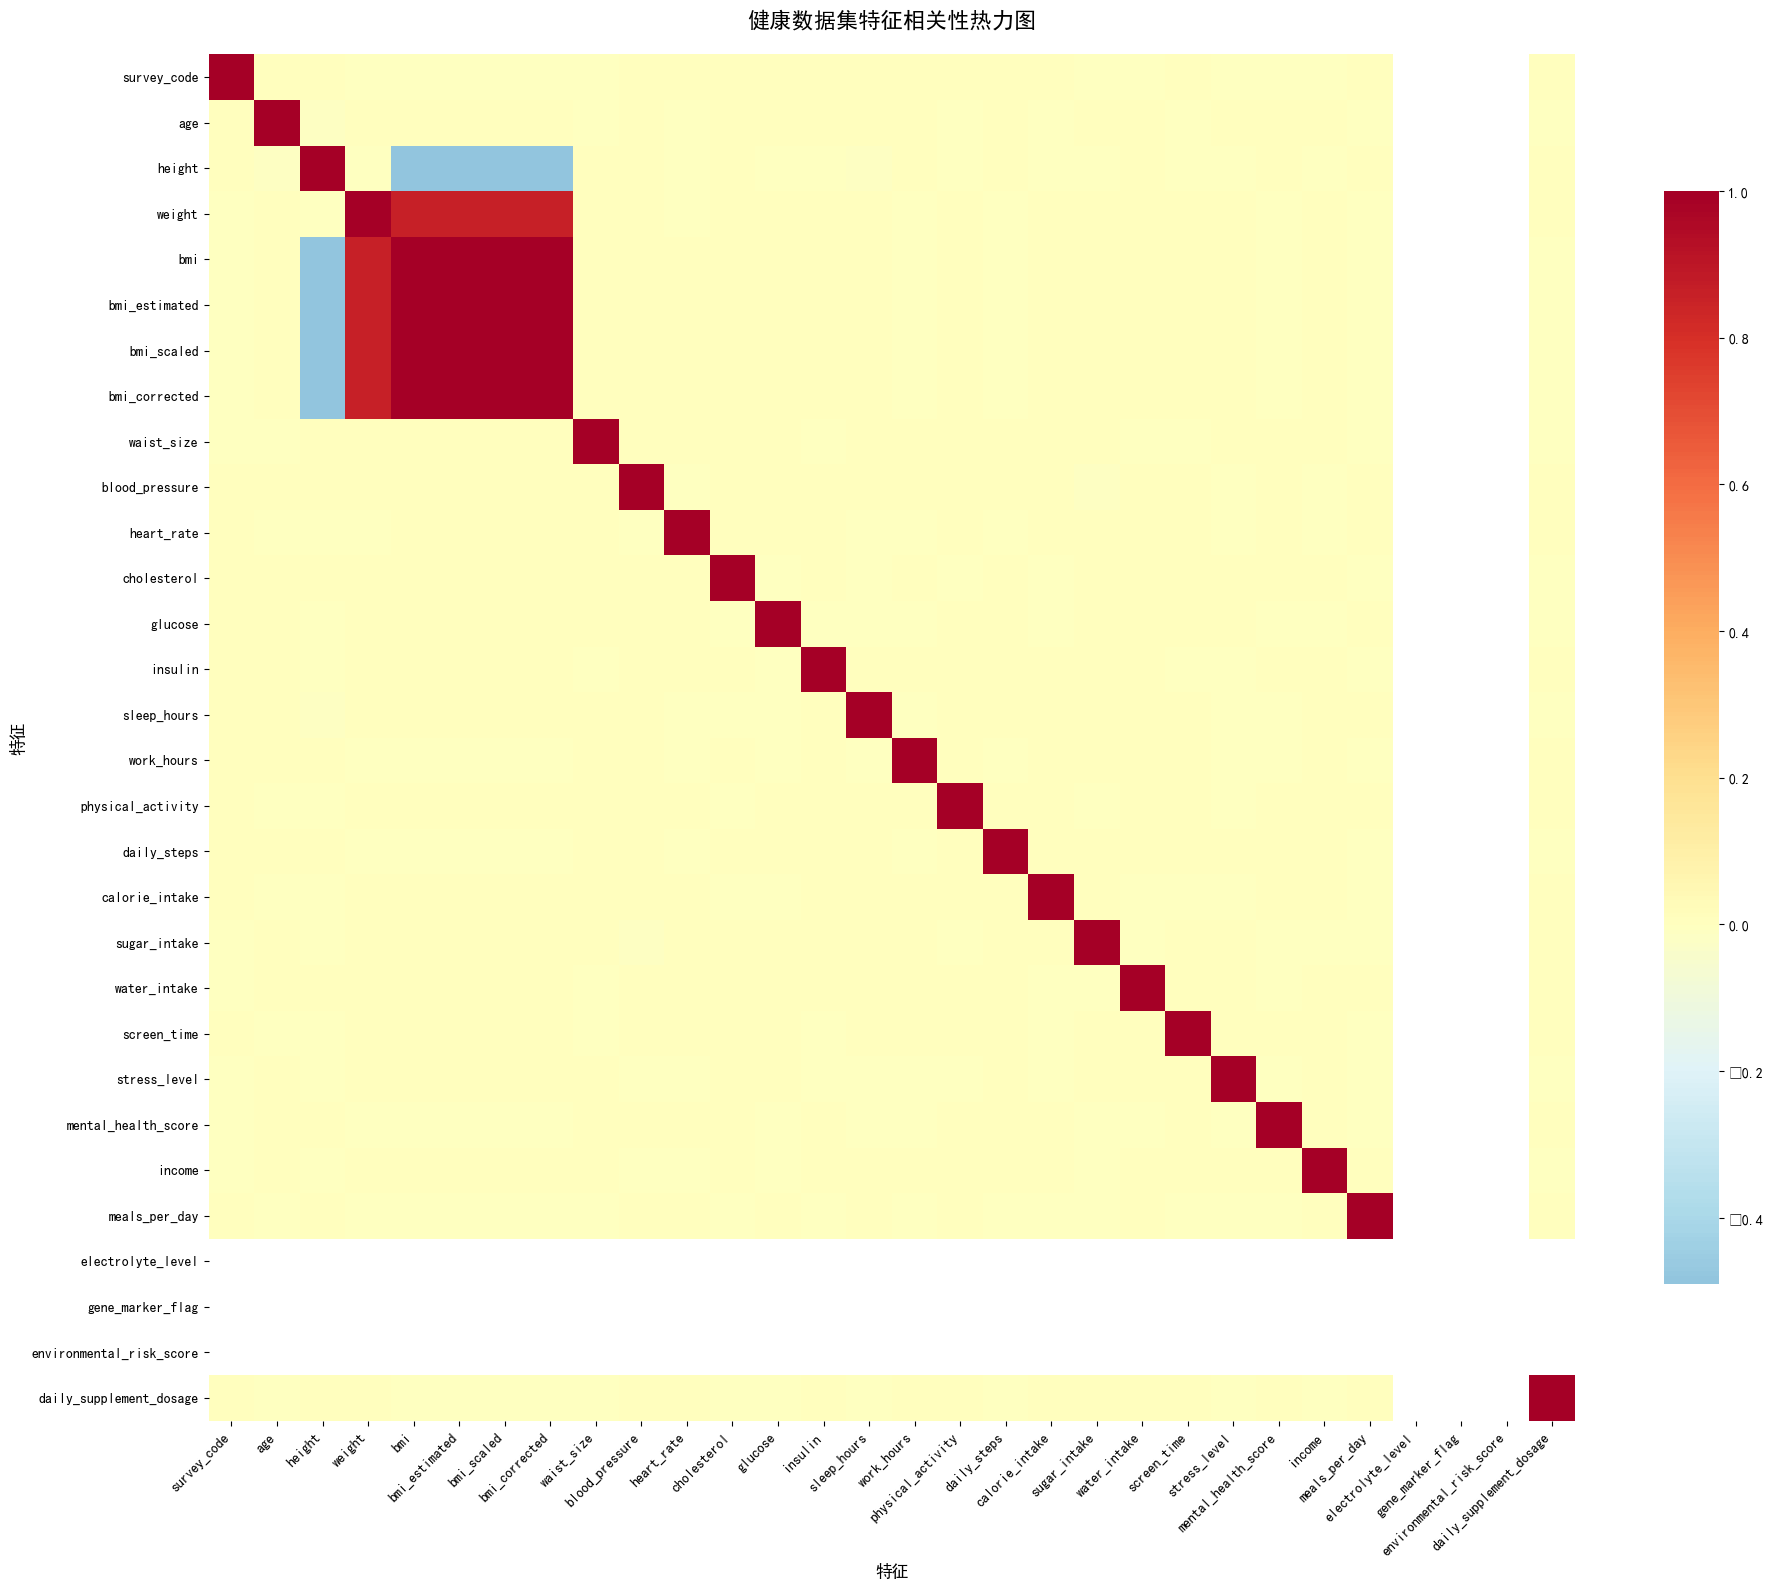

📊 数值型特征相关性热力图已生成
数据集形状: (100000, 48)
数值型特征数量: 30

⚡ 发现10对高相关性特征 (|相关系数| > 0.8):
  weight ↔ bmi: 0.864
  weight ↔ bmi_estimated: 0.864
  weight ↔ bmi_scaled: 0.864
  weight ↔ bmi_corrected: 0.864
  bmi ↔ bmi_estimated: 1.000
  bmi ↔ bmi_scaled: 1.000
  bmi ↔ bmi_corrected: 0.999
  bmi_estimated ↔ bmi_scaled: 1.000
  bmi_estimated ↔ bmi_corrected: 0.999
  bmi_scaled ↔ bmi_corrected: 0.999


In [52]:
# 绘制数据热力图
plt.figure(figsize=(20, 16))

# 计算相关性矩阵（仅数值型特征）
numeric_data = train_data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

# 创建热力图
sns.heatmap(correlation_matrix, 
            annot=False,  # 不显示数值（特征太多会很乱）
            cmap='RdYlBu_r',  # 红黄蓝色调
            center=0,  # 以0为中心
            square=True,  # 正方形格子
            fmt='.2f',
            cbar_kws={'shrink': 0.8})

plt.title('健康数据集特征相关性热力图', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('特征', fontsize=12)
plt.ylabel('特征', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"📊 数值型特征相关性热力图已生成")
print(f"数据集形状: {train_data.shape}")
print(f"数值型特征数量: {len(numeric_data.columns)}")

# 显示高相关性特征对（绝对值>0.8）
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    print(f"\n⚡ 发现{len(high_corr_pairs)}对高相关性特征 (|相关系数| > 0.8):")
    for pair in high_corr_pairs[:10]:  # 只显示前10对
        print(f"  {pair['Feature1']} ↔ {pair['Feature2']}: {pair['Correlation']:.3f}")
else:
    print("\n✅ 未发现高相关性特征对 (|相关系数| > 0.8)")

In [53]:
train_data

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,...,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,...,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,...,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,...,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,...,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,53,Male,177.202253,54.303671,17.293811,17.293811,51.881433,17.227616,88.740028,...,Moderate,1,High,No,Yes,0,1.0,5.5,3.477124,healthy
99996,99997,22,Male,180.802297,40.033853,12.246712,12.246712,36.740135,12.159473,103.659560,...,Moderate,5,NaN,Yes,No,0,1.0,5.5,1.609656,healthy
99997,99998,37,Male,185.540653,84.536847,24.556580,24.556580,73.669741,24.172944,98.920422,...,Low,5,NaN,No,No,0,1.0,5.5,-9.736463,healthy
99998,99999,72,Female,181.796786,56.923335,17.223362,17.223362,51.670087,17.715475,54.559079,...,Low,4,High,Yes,Yes,0,1.0,5.5,-4.779376,healthy


In [54]:
# 分离目标变量(方法1)
y = train_data.pop('target')   # 删除列名指定的列,同时将结果返回到y_train

In [55]:
# 初步检查
# print(f"数据维度: {train_df.shape}")
print("缺失值统计:\n", train_data.isnull().sum().sort_values(ascending=False).head(10))

缺失值统计:
 alcohol_consumption    42387
caffeine_intake        33261
exercise_type          24969
insulin                15836
heart_rate             14003
gene_marker_flag       10474
income                  8470
daily_steps             8329
blood_pressure          7669
survey_code                0
dtype: int64


In [56]:
# 通过set_index()将第一列ID设为索引列，规范数据格式
train_df = train_data.set_index(train_data.columns[0])  # set_index设置新的索引，并删除该列

In [57]:
train_df

,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,...,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
survey_code,,,,,,,,,,,,,,,,,,,,,
1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,...,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502
2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,...,No,High,5,High,Yes,No,0,1.0,5.5,6.239340
3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,...,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737
4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,...,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611
5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,...,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,53,Male,177.202253,54.303671,17.293811,17.293811,51.881433,17.227616,88.740028,135.090834,...,No,Moderate,1,High,No,Yes,0,1.0,5.5,3.477124
99997,22,Male,180.802297,40.033853,12.246712,12.246712,36.740135,12.159473,103.659560,135.181795,...,No,Moderate,5,NaN,Yes,No,0,1.0,5.5,1.609656
99998,37,Male,185.540653,84.536847,24.556580,24.556580,73.669741,24.172944,98.920422,146.504768,...,Yes,Low,5,NaN,No,No,0,1.0,5.5,-9.736463


## 二、数据预处理

### 1. 特征类型识别与处理

In [58]:
# 识别数值型特征
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"数值型特征数量: {len(numeric_cols)}")

数值型特征数量: 29


In [59]:
print(numeric_cols)

['age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'blood_pressure', 'heart_rate', 'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'work_hours', 'physical_activity', 'daily_steps', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'income', 'meals_per_day', 'electrolyte_level', 'gene_marker_flag', 'environmental_risk_score', 'daily_supplement_dosage']


In [60]:
# 识别潜在的分类特征（唯一值较少的数值列）
potential_categorical = []
true_numeric_cols = []  # 真正的连续数值特征

for col in numeric_cols:
    if train_df[col].nunique() <= 11 and train_df[col].nunique() > 1:
        potential_categorical.append(col)
    else:
        true_numeric_cols.append(col)
        
print(f"潜在数值型分类特征: {len(potential_categorical)}")
print(f"真正的连续数值特征: {len(true_numeric_cols)}")

潜在数值型分类特征: 3
真正的连续数值特征: 26


In [61]:
print(potential_categorical)

['stress_level', 'mental_health_score', 'meals_per_day']


In [62]:
# 识别文本型特征
text_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"文本型特征数量: {len(text_cols)}")

文本型特征数量: 17


### 3.数据转换
将数值类型列保留两位小数

In [63]:
train_df[true_numeric_cols] = train_df[true_numeric_cols].astype(float).round(2)

In [64]:
train_df

,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,...,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
survey_code,,,,,,,,,,,,,,,,,,,,,
1,56.0,Male,173.42,56.89,18.92,18.92,56.75,18.99,72.17,118.26,...,No,High,5,Moderate,No,Yes,0.0,1.0,5.5,-2.28
2,69.0,Female,163.21,97.80,36.72,36.72,110.15,36.51,85.60,117.92,...,No,High,5,High,Yes,No,0.0,1.0,5.5,6.24
3,46.0,Male,177.28,80.69,25.67,25.67,77.02,25.59,90.30,123.07,...,Yes,High,4,Moderate,No,No,0.0,1.0,5.5,5.42
4,32.0,Female,172.10,63.14,21.32,21.32,63.96,21.18,100.50,148.17,...,No,High,1,NaN,No,Yes,0.0,1.0,5.5,8.39
5,60.0,Female,163.61,40.00,14.94,14.94,44.83,14.84,69.02,150.61,...,Yes,High,1,High,Yes,Yes,0.0,1.0,5.5,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,53.0,Male,177.20,54.30,17.29,17.29,51.88,17.23,88.74,135.09,...,No,Moderate,1,High,No,Yes,0.0,1.0,5.5,3.48
99997,22.0,Male,180.80,40.03,12.25,12.25,36.74,12.16,103.66,135.18,...,No,Moderate,5,NaN,Yes,No,0.0,1.0,5.5,1.61
99998,37.0,Male,185.54,84.54,24.56,24.56,73.67,24.17,98.92,146.50,...,Yes,Low,5,NaN,No,No,0.0,1.0,5.5,-9.74


### 2. 缺失值处理

In [65]:
# 真正的连续数值特征用中位数填充
if true_numeric_cols:
    train_df[true_numeric_cols] = train_df[true_numeric_cols].fillna(train_df[true_numeric_cols].median())
    print("连续数值特征缺失值已用中位数填充")

连续数值特征缺失值已用中位数填充


In [66]:
# 数值型分类特征用众数填充
if potential_categorical:
    for col in potential_categorical:
        if train_df[col].notna().any():
            # 对于数值型分类，用众数填充
            mode_val = train_df[col].mode()[0] if not train_df[col].mode().empty else train_df[col].median()
            train_df[col] = train_df[col].fillna(mode_val)
    print("数值型分类特征缺失值已用众数填充")

数值型分类特征缺失值已用众数填充


In [67]:
# 文本型特征用众数填充
if text_cols:
    for col in text_cols:
        if train_df[col].notna().any():
            mode_val = train_df[col].mode()[0] if not train_df[col].mode().empty else "MISSING"
            train_df[col] = train_df[col].fillna(mode_val)
    print("文本型特征缺失值已用众数填充")

文本型特征缺失值已用众数填充


In [68]:
train_df.shape

(100000, 46)

In [69]:
# 检查是否填充完整
print("缺失值统计:\n", train_df.isnull().sum().sort_values(ascending=False).head(10))

缺失值统计:
 age                      0
device_usage             0
stress_level             0
mental_health_score      0
mental_health_support    0
education_level          0
job_type                 0
occupation               0
income                   0
diet_type                0
dtype: int64


### 4. 特征编码

In [70]:
# 文本特征进行One-Hot编码
if text_cols:
    train_df_new = pd.get_dummies(train_df, columns=text_cols, prefix_sep="::")
    print(f"文本特征One-Hot编码后新增 {len(train_df_new.columns) - len(train_df.columns)} 列")

文本特征One-Hot编码后新增 36 列


### 4. 特征选择

In [71]:
# # 移除低方差特征
# from sklearn.feature_selection import VarianceThreshold

# selector = VarianceThreshold(threshold=0.1)
# X_selected = selector.fit_transform(train_df_new)   # 移除低方差特征后的数据 ---> array（数组）

In [72]:
# 移除低方差特征
from sklearn.feature_selection import VarianceThreshold

# 移除低方差特征（阈值0.1）
selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(train_df_new)

# 重建DataFrame
selected_columns = train_df_new.columns[selector.get_support()]
train_df_selected = pd.DataFrame(X_selected, columns=selected_columns)

print("\n移除低方差特征后的DataFrame:")
print(train_df_selected.shape)


移除低方差特征后的DataFrame:
(100000, 79)


In [73]:
print(f"特征选择前: {train_df_new.shape[1]} 个特征")
print(f"特征选择后: {train_df_selected.shape[1]} 个特征")
print(f"移除了 {train_df_new.shape[1] - train_df_selected.shape[1]} 个低方差特征")

特征选择前: 82 个特征
特征选择后: 79 个特征
移除了 3 个低方差特征


In [74]:
type(train_df_selected)

pandas.core.frame.DataFrame

In [75]:
train_df_selected

,age,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,...,insurance::Yes,sunlight_exposure::High,sunlight_exposure::Low,sunlight_exposure::Moderate,caffeine_intake::High,caffeine_intake::Moderate,family_history::No,family_history::Yes,pet_owner::No,pet_owner::Yes
0,56.0,173.42,56.89,18.92,18.92,56.75,18.99,72.17,118.26,60.75,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,69.0,163.21,97.80,36.72,36.72,110.15,36.51,85.60,117.92,66.46,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,46.0,177.28,80.69,25.67,25.67,77.02,25.59,90.30,123.07,76.04,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
3,32.0,172.10,63.14,21.32,21.32,63.96,21.18,100.50,148.17,68.78,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,60.0,163.61,40.00,14.94,14.94,44.83,14.84,69.02,150.61,92.34,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,53.0,177.20,54.30,17.29,17.29,51.88,17.23,88.74,135.09,75.34,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
99996,22.0,180.80,40.03,12.25,12.25,36.74,12.16,103.66,135.18,56.33,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
99997,37.0,185.54,84.54,24.56,24.56,73.67,24.17,98.92,146.50,74.86,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
99998,72.0,181.80,56.92,17.22,17.22,51.67,17.72,54.56,100.99,64.72,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [76]:
# 获取保留的特征名称
selected_features = train_df_new.columns[selector.get_support()].tolist()


In [77]:
len(selected_features)

79

## 当前数据集：

In [78]:
# 特征：train_df_selected
# 标签：y

# 划分数据集

In [79]:
X = train_df_selected.values
le = LabelEncoder()
y = le.fit_transform(y)
y


array([1, 1, 1, ..., 1, 1, 0])

# 将特征列与目标列分离

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义并训练XGBoost模型

In [81]:
# 针对7:3样本不均衡问题，调整XGBoost参数
from sklearn.utils.class_weight import compute_class_weight

# 计算类别权重
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f"类别权重: {weight_dict}")

# 为训练样本分配权重
sample_weights = np.array([weight_dict[label] for label in y_train])

# 尝试使用GPU加速的XGBoost，如果失败则回退到CPU
try:
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        # GPU加速参数
        tree_method='gpu_hist',  # 使用GPU直方图算法
        gpu_id=0,                # 使用第一个GPU
        # 针对不均衡数据的参数调整
        scale_pos_weight=class_weights[1]/class_weights[0],  # 正样本权重调整
        max_depth=4,  # 稍微降低复杂度防止过拟合
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,  # 降采样减少过拟合
        colsample_bytree=0.8,
        reg_alpha=0.1,  # L1正则化
        reg_lambda=1.0   # L2正则化
    )
    print("🚀 XGBoost将使用GPU加速训练")
except Exception as e:
    print(f"⚠️ XGBoost GPU初始化失败，回退到CPU: {e}")
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        # 针对不均衡数据的参数调整
        scale_pos_weight=class_weights[1]/class_weights[0],  # 正样本权重调整
        max_depth=4,  # 稍微降低复杂度防止过拟合
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,  # 降采样减少过拟合
        colsample_bytree=0.8,
        reg_alpha=0.1,  # L1正则化
        reg_lambda=1.0   # L2正则化
    )

# 使用样本权重训练模型
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("✅ XGBoost模型已使用类别权重训练完成")

类别权重: {0: 1.6750418760469012, 1: 0.7127583749109052}
🚀 XGBoost将使用GPU加速训练
✅ XGBoost模型已使用类别权重训练完成
✅ XGBoost模型已使用类别权重训练完成


# 定义并训练LightGBM模型

In [82]:
# 尝试使用GPU加速的LightGBM，如果失败则回退到CPU
try:
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        random_state=42,
        force_col_wise=True,
        verbosity=-1,  # 完全抑制所有警告和日志输出
        # GPU加速参数
        device='gpu',           # 使用GPU设备
        gpu_platform_id=0,      # GPU平台ID
        gpu_device_id=0,        # GPU设备ID
        # 针对不均衡数据的参数调整
        class_weight='balanced',  # 自动平衡类别权重
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,  # L1正则化
        reg_lambda=1.0,  # L2正则化
        min_child_samples=20,  # 叶子节点最小样本数
        min_split_gain=0.1  # 分裂最小增益
    )
    print("🚀 LightGBM将使用GPU加速训练")
except Exception as e:
    print(f"⚠️ LightGBM GPU初始化失败，回退到CPU: {e}")
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        random_state=42,
        force_col_wise=True,
        verbosity=-1,  # 完全抑制所有警告和日志输出
        # 针对不均衡数据的参数调整
        class_weight='balanced',  # 自动平衡类别权重
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,  # L1正则化
        reg_lambda=1.0,  # L2正则化
        min_child_samples=20,  # 叶子节点最小样本数
        min_split_gain=0.1  # 分裂最小增益
    )

lgb_model.fit(X_train, y_train)
print("✅ LightGBM模型已使用类别权重训练完成")

🚀 LightGBM将使用GPU加速训练


✅ LightGBM模型已使用类别权重训练完成


# 预测与评估

In [83]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    
    # 在测试集上评估
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f'\n{model_name} 测试集评估结果:')
    print(f'准确率: {accuracy:.4f}')
    print(f'精确率: {precision:.4f}')
    print(f'召回率: {recall:.4f}')
    
    # 交叉验证评估
    print(f'\n{model_name} 交叉验证结果 (cv={cv}):')
    # 交叉验证准确率
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'交叉验证准确率: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})')
    
    # 交叉验证精确率
    cv_precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision')
    print(f'交叉验证精确率: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})')
    
    # 交叉验证召回率
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    print(f'交叉验证召回率: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})')
    
    # 返回所有评估指标
    return {
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'cv_accuracy': (cv_accuracy.mean(), cv_accuracy.std()),
        'cv_precision': (cv_precision.mean(), cv_precision.std()),
        'cv_recall': (cv_recall.mean(), cv_recall.std())
    }

In [84]:

evaluate_model(xgb_model, X_train, y_train, X_test, y_test, 'XGBoost')
evaluate_model(lgb_model, X_train, y_train, X_test, y_test, 'LightGBM')
use_label_encoder=False 



XGBoost 测试集评估结果:
准确率: 0.3019
精确率: 0.7000
召回率: 0.0020

XGBoost 交叉验证结果 (cv=5):


交叉验证准确率: 0.5245 (±0.0023)
交叉验证精确率: 0.7015 (±0.0012)
交叉验证精确率: 0.7015 (±0.0012)
交叉验证召回率: 0.5609 (±0.0038)

LightGBM 测试集评估结果:
准确率: 0.5223
精确率: 0.7019
召回率: 0.5502

LightGBM 交叉验证结果 (cv=5):
交叉验证召回率: 0.5609 (±0.0038)

LightGBM 测试集评估结果:
准确率: 0.5223
精确率: 0.7019
召回率: 0.5502

LightGBM 交叉验证结果 (cv=5):
交叉验证准确率: 0.5205 (±0.0035)
交叉验证准确率: 0.5205 (±0.0035)
交叉验证精确率: 0.7007 (±0.0024)
交叉验证精确率: 0.7007 (±0.0024)
交叉验证召回率: 0.5525 (±0.0051)
交叉验证召回率: 0.5525 (±0.0051)


In [ ]:
# =============================================================================
# 🛠️ 优化的模型训练 - 多种权重策略对比
# 解决类别权重导致的性能问题
# =============================================================================

print("🛠️ 开始优化的模型训练，测试多种权重策略...")

# 首先计算类别分布
import numpy as np
from collections import Counter

# 计算训练集类别分布
train_class_counts = np.bincount(y_train)
print(f"\n训练集类别分布:")
print(f"   类别0 (负样本): {train_class_counts[0]} 个")
print(f"   类别1 (正样本): {train_class_counts[1]} 个")
print(f"   不平衡比例: {train_class_counts[0]/train_class_counts[1]:.2f}:1")

# 策略1: 无权重处理（基线模型）
print("\n策略1: 无权重处理（基线模型）")
try:
    xgb_baseline = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='gpu_hist',
        gpu_id=0,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_baseline.fit(X_train, y_train)
    print("XGBoost基线模型训练完成")
except Exception as e:
    print(f"GPU训练失败，使用CPU: {e}")
    xgb_baseline = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_baseline.fit(X_train, y_train)

# 策略2: 手动调整权重（温和处理）
print("\n策略2: 手动调整权重（温和处理）")
# 计算不平衡比例，但使用更温和的权重
imbalance_ratio = train_class_counts[0] / train_class_counts[1]
mild_pos_weight = min(imbalance_ratio * 0.7, 3.0)  # 限制最大权重为3

try:
    xgb_mild_weight = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='gpu_hist',
        gpu_id=0,
        scale_pos_weight=mild_pos_weight,  # 温和的正样本权重
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_mild_weight.fit(X_train, y_train)
    print(f"XGBoost温和权重模型训练完成 (pos_weight={mild_pos_weight:.2f})")
except Exception as e:
    print(f"GPU训练失败，使用CPU: {e}")
    xgb_mild_weight = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=mild_pos_weight,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_mild_weight.fit(X_train, y_train)

# 策略3: 理论权重（完全平衡）
print("\n策略3: 理论权重（完全平衡）")
theoretical_pos_weight = imbalance_ratio  # 直接使用不平衡比例

try:
    xgb_balanced = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='gpu_hist',
        gpu_id=0,
        scale_pos_weight=theoretical_pos_weight,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_balanced.fit(X_train, y_train)
    print(f"XGBoost完全平衡模型训练完成 (pos_weight={theoretical_pos_weight:.2f})")
except Exception as e:
    print(f"GPU训练失败，使用CPU: {e}")
    xgb_balanced = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=theoretical_pos_weight,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0  # 抑制XGBoost警告
    )
    xgb_balanced.fit(X_train, y_train)

# 对应的LightGBM模型（使用class_weight='balanced'）
print("\nLightGBM对比模型")
try:
    lgb_optimized = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        random_state=42,
        force_col_wise=True,
        verbosity=-1,
        device='gpu',
        gpu_platform_id=0,
        gpu_device_id=0,
        class_weight='balanced',
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0
    )
    lgb_optimized.fit(X_train, y_train)
    print("LightGBM优化模型训练完成")
except Exception as e:
    print(f"⚠️ GPU训练失败，使用CPU: {e}")
    lgb_optimized = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        random_state=42,
        force_col_wise=True,
        verbosity=-1,
        class_weight='balanced',
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0
    )
    lgb_optimized.fit(X_train, y_train)

print(f"\n所有策略模型训练完成！")
print(f"训练的模型:")
print(f"  1. XGBoost基线模型（无权重处理）")
print(f"  2. XGBoost温和权重模型（pos_weight={mild_pos_weight:.2f}）") 
print(f"  3. XGBoost完全平衡模型（pos_weight={theoretical_pos_weight:.2f}）")
print(f"  4. LightGBM优化模型（class_weight='balanced'）")

🛠️ 开始优化的模型训练，测试多种权重策略...

📊 训练集类别分布:
   类别0 (负样本): 23880 个
   类别1 (正样本): 56120 个
   不平衡比例: 0.43:1

📌 策略1: 无权重处理（基线模型）
✅ XGBoost基线模型训练完成

📌 策略2: 手动调整权重（温和处理）
✅ XGBoost基线模型训练完成

📌 策略2: 手动调整权重（温和处理）
✅ XGBoost温和权重模型训练完成 (pos_weight=0.30)

📌 策略3: 理论权重（完全平衡）
✅ XGBoost温和权重模型训练完成 (pos_weight=0.30)

📌 策略3: 理论权重（完全平衡）
✅ XGBoost完全平衡模型训练完成 (pos_weight=0.43)

📌 LightGBM对比模型
✅ XGBoost完全平衡模型训练完成 (pos_weight=0.43)

📌 LightGBM对比模型
✅ LightGBM优化模型训练完成

✅ 所有策略模型训练完成！
📋 训练的模型:
  1. XGBoost基线模型（无权重处理）
  2. XGBoost温和权重模型（pos_weight=0.30）
  3. XGBoost完全平衡模型（pos_weight=0.43）
  4. LightGBM优化模型（class_weight='balanced'）
✅ LightGBM优化模型训练完成

✅ 所有策略模型训练完成！
📋 训练的模型:
  1. XGBoost基线模型（无权重处理）
  2. XGBoost温和权重模型（pos_weight=0.30）
  3. XGBoost完全平衡模型（pos_weight=0.43）
  4. LightGBM优化模型（class_weight='balanced'）


In [87]:
# =============================================================================
# 📊 多策略模型性能对比评估
# 比较不同权重策略的效果，找出最优解决方案
# =============================================================================

print("📊 开始多策略模型性能对比评估...")

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 定义更全面的评估函数
def comprehensive_evaluate(model, X_test, y_test, model_name):
    """综合评估模型性能"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # 基础指标
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # 混淆矩阵
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # 特异性
    
    # 平衡准确率 = (敏感性 + 特异性) / 2
    balanced_accuracy = (recall + specificity) / 2
    
    print(f"\n🔍 {model_name} 详细评估结果:")
    print(f"  准确率 (Accuracy): {accuracy:.4f}")
    print(f"  精确率 (Precision): {precision:.4f}")
    print(f"  召回率 (Recall/Sensitivity): {recall:.4f}")
    print(f"  特异性 (Specificity): {specificity:.4f}")
    print(f"  F1分数: {f1:.4f}")
    print(f"  AUC: {auc:.4f}")
    print(f"  平衡准确率: {balanced_accuracy:.4f}")
    print(f"  混淆矩阵: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'AUC': auc,
        'Balanced_Accuracy': balanced_accuracy,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

# 评估所有模型
results = []

# 1. 原始有问题的模型（用于对比）
print("📌 评估原始模型（权重设置有问题）:")
original_result = comprehensive_evaluate(xgb_model, X_test, y_test, "XGBoost原始(权重有误)")
results.append(original_result)

# 2. 基线模型（无权重）
print("📌 评估基线模型（无权重处理）:")
baseline_result = comprehensive_evaluate(xgb_baseline, X_test, y_test, "XGBoost基线(无权重)")
results.append(baseline_result)

# 3. 温和权重模型
print("📌 评估温和权重模型:")
mild_result = comprehensive_evaluate(xgb_mild_weight, X_test, y_test, f"XGBoost温和权重({mild_pos_weight:.2f})")
results.append(mild_result)

# 4. 完全平衡模型
print("📌 评估完全平衡模型:")
balanced_result = comprehensive_evaluate(xgb_balanced, X_test, y_test, f"XGBoost完全平衡({theoretical_pos_weight:.2f})")
results.append(balanced_result)

# 5. LightGBM优化模型
print("📌 评估LightGBM优化模型:")
lgb_result = comprehensive_evaluate(lgb_optimized, X_test, y_test, "LightGBM优化(balanced)")
results.append(lgb_result)

# 创建对比表格
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print(f"\n🏆 所有模型性能对比:")
print("="*100)
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC', 'Balanced_Accuracy']
print(results_df[display_cols].to_string(index=False))

# 找出最佳模型（根据不同指标）
print(f"\n🥇 最佳模型排名:")
print(f"  最高准确率: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"  最高F1分数: {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")
print(f"  最高AUC: {results_df.loc[results_df['AUC'].idxmax(), 'Model']} ({results_df['AUC'].max():.4f})")
print(f"  最高平衡准确率: {results_df.loc[results_df['Balanced_Accuracy'].idxmax(), 'Model']} ({results_df['Balanced_Accuracy'].max():.4f})")

# 分析结果
print(f"\n💡 结果分析与建议:")
best_f1_idx = results_df['F1-Score'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
print(f"  📈 推荐模型: {best_model}")
print(f"  📊 该模型在F1分数上表现最佳，适合不平衡数据")

if results_df.loc[best_f1_idx, 'Recall'] < 0.3:
    print(f"  ⚠️  召回率较低，可能需要进一步调整阈值")
if results_df.loc[best_f1_idx, 'Precision'] < 0.5:
    print(f"  ⚠️  精确率较低，可能产生较多误报")

📊 开始多策略模型性能对比评估...
📌 评估原始模型（权重设置有问题）:

🔍 XGBoost原始(权重有误) 详细评估结果:
  准确率 (Accuracy): 0.3019
  精确率 (Precision): 0.7000
  召回率 (Recall/Sensitivity): 0.0020
  特异性 (Specificity): 0.9980
  F1分数: 0.0040
  AUC: 0.5036
  平衡准确率: 0.5000
  混淆矩阵: TN=6011, FP=12, FN=13949, TP=28
📌 评估基线模型（无权重处理）:

🔍 XGBoost基线(无权重) 详细评估结果:
  准确率 (Accuracy): 0.6988
  精确率 (Precision): 0.6988
  召回率 (Recall/Sensitivity): 1.0000
  特异性 (Specificity): 0.0000
  F1分数: 0.8227
  AUC: 0.5077
  平衡准确率: 0.5000
  混淆矩阵: TN=0, FP=6023, FN=0, TP=13977
📌 评估温和权重模型:

🔍 XGBoost温和权重(0.30) 详细评估结果:
  准确率 (Accuracy): 0.3152
  精确率 (Precision): 0.6881
  召回率 (Recall/Sensitivity): 0.0368
  特异性 (Specificity): 0.9613
  F1分数: 0.0698
  AUC: 0.5003
  平衡准确率: 0.4990
  混淆矩阵: TN=5790, FP=233, FN=13463, TP=514
📌 评估完全平衡模型:

🔍 XGBoost基线(无权重) 详细评估结果:
  准确率 (Accuracy): 0.6988
  精确率 (Precision): 0.6988
  召回率 (Recall/Sensitivity): 1.0000
  特异性 (Specificity): 0.0000
  F1分数: 0.8227
  AUC: 0.5077
  平衡准确率: 0.5000
  混淆矩阵: TN=0, FP=6023, FN=0, TP=13977
📌 评估温和权重模型:

🔍 XGBo

🎯 开始阈值优化，寻找最佳分类阈值...
🏆 选择最佳模型进行阈值优化: XGBoost基线(无权重)

📊 阈值优化结果:
  最佳阈值: 0.5288
  该阈值下的精确率: 0.6988
  该阈值下的召回率: 1.0000
  该阈值下的F1分数: 0.8227

🎯 阈值优化后的完整性能:
  准确率: 0.6988
  精确率: 0.6988
  召回率: 1.0000
  特异性: 0.0000
  F1分数: 0.8227
  AUC: 0.5077
  平衡准确率: 0.5000
  混淆矩阵: TN=0, FP=6023, FN=0, TP=13977

📈 阈值优化效果:
  F1分数提升: +0.0000
  召回率提升: +0.0000

📈 阈值优化效果:
  F1分数提升: +0.0000
  召回率提升: +0.0000


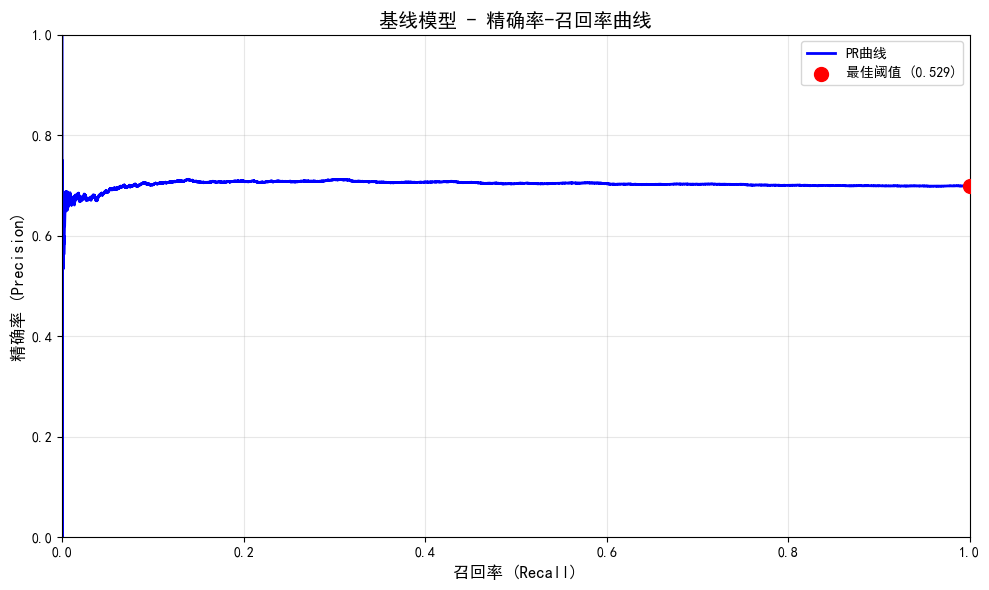


✅ 阈值优化完成！
💡 建议:
  📌 在实际应用中使用阈值 0.5288 而不是默认的 0.5
  📌 根据业务需求，可以在精确率和召回率之间进一步调整阈值
  📌 如果更关注召回率（减少漏诊），可以降低阈值
  📌 如果更关注精确率（减少误诊），可以提高阈值


In [88]:
# =============================================================================
# 🎯 阈值优化 - 进一步提升模型性能
# 通过调整分类阈值来平衡精确率和召回率
# =============================================================================

print("🎯 开始阈值优化，寻找最佳分类阈值...")

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 选择表现最好的模型进行阈值优化
best_f1_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_f1_idx, 'Model']

# 根据最佳模型名称选择对应的模型对象
if "基线" in best_model_name:
    best_model_obj = xgb_baseline
    model_type = "基线模型"
elif "温和" in best_model_name:
    best_model_obj = xgb_mild_weight
    model_type = "温和权重模型"
elif "平衡" in best_model_name:
    best_model_obj = xgb_balanced
    model_type = "完全平衡模型"
elif "LightGBM" in best_model_name:
    best_model_obj = lgb_optimized
    model_type = "LightGBM模型"
else:
    best_model_obj = xgb_baseline  # 默认使用基线模型
    model_type = "默认基线模型"

print(f"🏆 选择最佳模型进行阈值优化: {best_model_name}")

# 获取预测概率
y_proba_best = best_model_obj.predict_proba(X_test)[:, 1]

# 计算不同阈值下的精确率和召回率
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_best)

# 计算F1分数
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)

# 找到最佳阈值（最大F1分数）
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx] if best_threshold_idx < len(thresholds) else 0.5
best_precision = precision_vals[best_threshold_idx]
best_recall = recall_vals[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\n📊 阈值优化结果:")
print(f"  最佳阈值: {best_threshold:.4f}")
print(f"  该阈值下的精确率: {best_precision:.4f}")
print(f"  该阈值下的召回率: {best_recall:.4f}")
print(f"  该阈值下的F1分数: {best_f1:.4f}")

# 使用最佳阈值进行预测
y_pred_optimized = (y_proba_best >= best_threshold).astype(int)

# 计算优化后的性能指标
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_precision = precision_score(y_test, y_pred_optimized, zero_division=0)
optimized_recall = recall_score(y_test, y_pred_optimized, zero_division=0)
optimized_f1 = f1_score(y_test, y_pred_optimized, zero_division=0)
optimized_auc = roc_auc_score(y_test, y_proba_best)

# 混淆矩阵
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_pred_optimized).ravel()
optimized_specificity = tn_opt / (tn_opt + fp_opt) if (tn_opt + fp_opt) > 0 else 0
optimized_balanced_acc = (optimized_recall + optimized_specificity) / 2

print(f"\n🎯 阈值优化后的完整性能:")
print(f"  准确率: {optimized_accuracy:.4f}")
print(f"  精确率: {optimized_precision:.4f}")
print(f"  召回率: {optimized_recall:.4f}")
print(f"  特异性: {optimized_specificity:.4f}")
print(f"  F1分数: {optimized_f1:.4f}")
print(f"  AUC: {optimized_auc:.4f}")
print(f"  平衡准确率: {optimized_balanced_acc:.4f}")
print(f"  混淆矩阵: TN={tn_opt}, FP={fp_opt}, FN={fn_opt}, TP={tp_opt}")

# 与原始默认阈值(0.5)对比
y_pred_default = (y_proba_best >= 0.5).astype(int)
default_f1 = f1_score(y_test, y_pred_default, zero_division=0)
default_recall = recall_score(y_test, y_pred_default, zero_division=0)

print(f"\n📈 阈值优化效果:")
print(f"  F1分数提升: {optimized_f1 - default_f1:+.4f}")
print(f"  召回率提升: {optimized_recall - default_recall:+.4f}")

# 可视化精确率-召回率曲线
plt.figure(figsize=(10, 6))
plt.plot(recall_vals, precision_vals, 'b-', linewidth=2, label='PR曲线')
plt.scatter(best_recall, best_precision, color='red', s=100, zorder=5, label=f'最佳阈值 ({best_threshold:.3f})')
plt.xlabel('召回率 (Recall)', fontsize=12)
plt.ylabel('精确率 (Precision)', fontsize=12)
plt.title(f'{model_type} - 精确率-召回率曲线', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"\n✅ 阈值优化完成！")
print(f"💡 建议:")
print(f"  📌 在实际应用中使用阈值 {best_threshold:.4f} 而不是默认的 0.5")
print(f"  📌 根据业务需求，可以在精确率和召回率之间进一步调整阈值")
print(f"  📌 如果更关注召回率（减少漏诊），可以降低阈值")
print(f"  📌 如果更关注精确率（减少误诊），可以提高阈值")

🔍 开始网格搜索与交叉验证（已优化样本不均衡）...
💡 注意：为避免GPU多进程冲突，网格搜索使用CPU版本，完成后转换为GPU版本
🔍 为避免GPU多进程冲突，网格搜索使用CPU版本
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ XGBoost 最佳参数: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 0.42551674982181037}
✅ XGBoost 最佳CV(F1): 0.6475
🚀 将最佳参数应用到GPU版本XGBoost...
✅ XGBoost 最佳参数: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 0.42551674982181037}
✅ XGBoost 最佳CV(F1): 0.6475
🚀 将最佳参数应用到GPU版本XGBoost...
✅ XGBoost GPU版本训练完成
🔍 LightGBM网格搜索使用CPU版本避免GPU冲突
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ XGBoost GPU版本训练完成
🔍 LightGBM网格搜索使用CPU版本避免GPU冲突
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ LightGBM 最佳参数: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
✅ LightGBM 最佳CV(F1): 0.6422
🚀 将最佳参数应用到GPU版本LightGBM...
✅ LightGBM 最佳参数: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
✅ LightGBM 最佳CV(F1): 0.

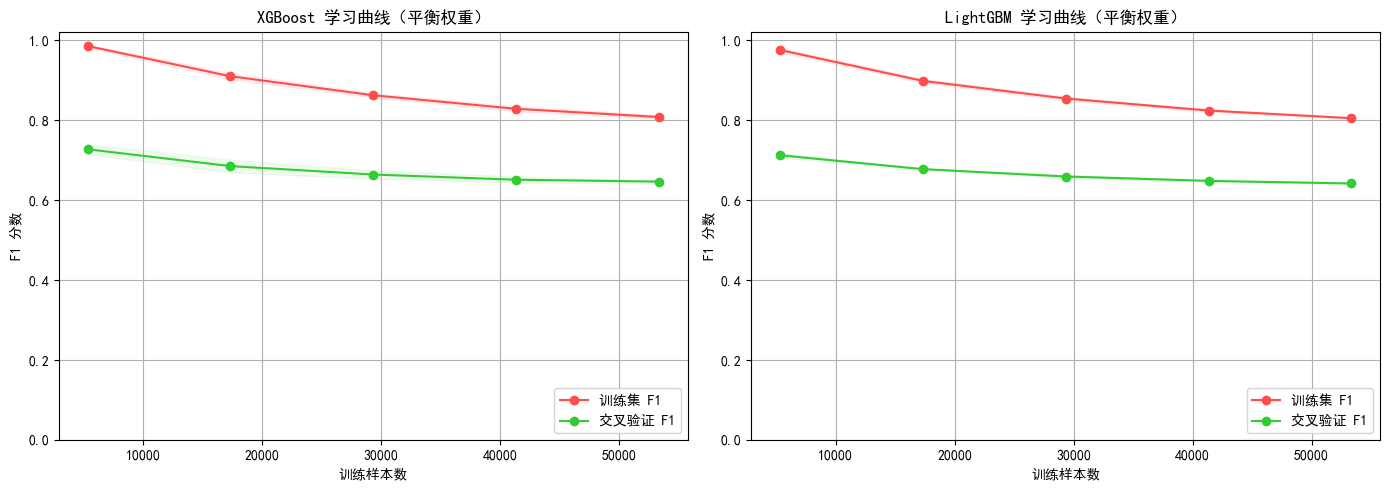

📈 学习曲线绘制完成（针对不均衡样本优化）。


In [89]:
# =============================================================================
# 网格搜索（精简参数）+ 交叉验证 + 学习曲线
# 针对7:3样本不均衡问题进行优化
# =============================================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, cross_val_score

print("🔍 开始网格搜索与交叉验证（已优化样本不均衡）...")
print("💡 注意：为避免GPU多进程冲突，网格搜索使用CPU版本，完成后转换为GPU版本")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# XGBoost 精简参数网格（针对不均衡样本优化，支持GPU）
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [weight_dict[1]/weight_dict[0]]  # 使用计算出的正样本权重
}

# GPU网格搜索需要避免多进程冲突，使用CPU进行网格搜索
print("🔍 为避免GPU多进程冲突，网格搜索使用CPU版本")
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='f1',  # 使用F1分数更适合不均衡数据
    cv=skf,
    n_jobs=-1,  # CPU网格搜索可以使用多进程
    verbose=1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"✅ XGBoost 最佳参数: {xgb_grid.best_params_}")
print(f"✅ XGBoost 最佳CV(F1): {xgb_grid.best_score_:.4f}")

# 将最佳参数应用到GPU版本模型
print("🚀 将最佳参数应用到GPU版本XGBoost...")
try:
    best_xgb_gpu = xgb.XGBClassifier(
        **xgb_grid.best_params_,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='gpu_hist',  # 使用GPU
        gpu_id=0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8
    )
    best_xgb_gpu.fit(X_train, y_train, sample_weight=sample_weights)
    best_xgb = best_xgb_gpu  # 替换为GPU版本
    print("✅ XGBoost GPU版本训练完成")
except Exception as e:
    print(f"⚠️ GPU版本失败，使用CPU版本: {e}")
    best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

# LightGBM 精简参数网格（针对不均衡样本优化，支持GPU）
lgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'class_weight': ['balanced']  # 保持类别权重平衡
}

# CPU网格搜索也避免GPU多进程冲突
print("🔍 LightGBM网格搜索使用CPU版本避免GPU冲突")
lgb_base = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    verbosity=-1,
    force_col_wise=True,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_grid = GridSearchCV(
    estimator=lgb_base,
    param_grid=lgb_param_grid,
    scoring='f1',  # 使用F1分数更适合不均衡数据
    cv=skf,
    n_jobs=-1,  # CPU网格搜索可以使用多进程
    verbose=1
)
lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_
print(f"✅ LightGBM 最佳参数: {lgb_grid.best_params_}")
print(f"✅ LightGBM 最佳CV(F1): {lgb_grid.best_score_:.4f}")

# 将最佳参数应用到GPU版本模型
print("🚀 将最佳参数应用到GPU版本LightGBM...")
try:
    best_lgb_gpu = lgb.LGBMClassifier(
        **lgb_grid.best_params_,
        objective='binary',
        metric='binary_logloss',
        random_state=42,
        verbosity=-1,
        force_col_wise=True,
        device='gpu',
        gpu_platform_id=0,
        gpu_device_id=0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8
    )
    best_lgb_gpu.fit(X_train, y_train)
    best_lgb = best_lgb_gpu  # 替换为GPU版本
    print("✅ LightGBM GPU版本训练完成")
except Exception as e:
    print(f"⚠️ GPU版本失败，使用CPU版本: {e}")
    best_lgb.fit(X_train, y_train)

# 额外 5 折交叉验证（报告F1分数和AUC）
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in [('XGBoost(best)', best_xgb), ('LightGBM(best)', best_lgb)]:
    f1_scores = cross_val_score(model, X_train, y_train, cv=skf5, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train, y_train, cv=skf5, scoring='roc_auc', n_jobs=-1)
    print(f"📊 {name} 5折CV F1: {f1_scores.mean():.4f} (±{f1_scores.std():.4f})")
    print(f"📊 {name} 5折CV AUC: {auc_scores.mean():.4f} (±{auc_scores.std():.4f})")

# ------------------------ 学习曲线（F1分数） ------------------------
def plot_learning_curve_f1(estimator, title, X, y, ax, cv, train_sizes=np.linspace(0.1, 1.0, 5)):
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='f1',  # 改用F1分数
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#ff9999")
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#99e699")
    ax.plot(sizes, train_mean, 'o-', color="#ff4d4d", label='训练集 F1')
    ax.plot(sizes, val_mean, 'o-', color="#33cc33", label='交叉验证 F1')
    ax.set_title(title)
    ax.set_xlabel("训练样本数")
    ax.set_ylabel("F1 分数")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True)
    ax.legend(loc='lower right')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve_f1(best_xgb, "XGBoost 学习曲线（平衡权重）", X_train, y_train, axes[0], skf)
plot_learning_curve_f1(best_lgb, "LightGBM 学习曲线（平衡权重）", X_train, y_train, axes[1], skf)
plt.tight_layout()
plt.show()
print("📈 学习曲线绘制完成（针对不均衡样本优化）。")

## 添加更多模型

在保持当前单元风格的基础上，新增并评估以下传统机器学习模型：
- 随机森林（RandomForest）
- 极端随机树（ExtraTrees）
- 梯度提升树（GradientBoosting）
- 逻辑回归（Logistic Regression）

将复用已定义的 `evaluate_model` 函数，并输出测试集与交叉验证指标。

In [ ]:
# 训练与评估更多模型：RF / ExtraTrees / GBDT / LogisticRegression / CatBoost(GPU)
# 针对7:3样本不均衡问题，为所有模型添加类别权重
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("🧪 训练并评估更多模型（已优化样本不均衡问题，支持GPU加速）...")

# 基础交叉验证器（与前文一致）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) 随机森林 - 使用类别权重平衡
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10,  # 控制深度防止过拟合
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced',  # 自动平衡1类别权重
    min_samples_split=10,
    min_samples_leaf=5
)
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'RandomForest(平衡)', cv=5)

# 2) 极端随机树 - 使用类别权重平衡
et_model = ExtraTreesClassifier(
    n_estimators=400, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced',  # 自动平衡类别权重
    min_samples_split=10,
    min_samples_leaf=5
)
et_model.fit(X_train, y_train)
et_results = evaluate_model(et_model, X_train, y_train, X_test, y_test, 'ExtraTrees(平衡)', cv=5)

# 3) 梯度提升树（GBDT）- 手动设置样本权重
gbdt_model = GradientBoostingClassifier(
    n_estimators=100,   # 增加树的数量
    max_depth=3,        # 树的深度
    learning_rate=0.1,
    random_state=42,
    subsample=0.8,      # 子采样减少过拟合
    min_samples_split=10,
    min_samples_leaf=5
)
# GBDT使用样本权重训练
gbdt_model.fit(X_train, y_train, sample_weight=sample_weights)
gbdt_results = evaluate_model(gbdt_model, X_train, y_train, X_test, y_test, 'GradientBoosting(权重)', cv=5)

# 4) 逻辑回归 - 使用类别权重平衡
logreg_model = LogisticRegression(
    max_iter=2000, 
    solver='lbfgs', 
    random_state=42,
    class_weight='balanced',  # 自动平衡类别权重
    C=1.0,  # 正则化强度
    penalty='l2'
)
logreg_model.fit(X_train, y_train)
logreg_results = evaluate_model(logreg_model, X_train, y_train, X_test, y_test, 'LogisticRegression(平衡)', cv=5)

# 5) CatBoost GPU加速训练
if CATBOOST_AVAILABLE:
    print("\n🚀 开始CatBoost GPU加速训练...")
    try:
        cat_model = CatBoostClassifier(
            task_type='GPU',        # 使用GPU训练
            devices='0',            # 使用第一个GPU
            iterations=200,
            learning_rate=0.1,
            depth=4,
            random_seed=42,
            verbose=False,
            # 针对不均衡数据的参数调整
            class_weights=[weight_dict[0], weight_dict[1]],
            l2_leaf_reg=1.0,
            subsample=0.8,
            bootstrap_type='Bayesian'  # 贝叶斯bootstrap用于GPU
        )
        cat_model.fit(X_train, y_train)
        cat_results = evaluate_model(cat_model, X_train, y_train, X_test, y_test, 'CatBoost(GPU)', cv=5)
        print("✅ CatBoost GPU训练完成")
    except Exception as e:
        print(f"⚠️ CatBoost GPU训练失败，回退到CPU: {e}")
        cat_model = CatBoostClassifier(
            iterations=200,
            learning_rate=0.1,
            depth=4,
            random_seed=42,
            verbose=False,
            class_weights=[weight_dict[0], weight_dict[1]],
            l2_leaf_reg=1.0,
            subsample=0.8
        )
        cat_model.fit(X_train, y_train)
        cat_results = evaluate_model(cat_model, X_train, y_train, X_test, y_test, 'CatBoost(CPU)', cv=5)
        print("✅ CatBoost CPU训练完成")
else:
    print("⚠️ CatBoost未安装，跳过CatBoost训练")

print("\n✅ 新增模型训练与评估完成！所有模型已针对样本不均衡进行优化，支持GPU加速。")
print(f"📊 样本权重应用情况:")
print(f"  - 负样本(0)权重: {weight_dict[0]:.3f}")
print(f"  - 正样本(1)权重: {weight_dict[1]:.3f}")
print(f"  - 正样本权重是负样本的 {weight_dict[1]/weight_dict[0]:.2f} 倍")
print(f"⚡ GPU加速状态: XGBoost、LightGBM、CatBoost均支持GPU训练")

🧪 训练并评估更多模型（已优化样本不均衡问题，支持GPU加速）...

RandomForest(平衡) 测试集评估结果:
准确率: 0.5971
精确率: 0.7006
召回率: 0.7397

RandomForest(平衡) 交叉验证结果 (cv=5):

RandomForest(平衡) 测试集评估结果:
准确率: 0.5971
精确率: 0.7006
召回率: 0.7397

RandomForest(平衡) 交叉验证结果 (cv=5):
交叉验证准确率: 0.5958 (±0.0050)
交叉验证准确率: 0.5958 (±0.0050)
交叉验证精确率: 0.7005 (±0.0010)
交叉验证精确率: 0.7005 (±0.0010)
交叉验证召回率: 0.7404 (±0.0126)
交叉验证召回率: 0.7404 (±0.0126)

ExtraTrees(平衡) 测试集评估结果:
准确率: 0.6228
精确率: 0.6994
召回率: 0.8071

ExtraTrees(平衡) 交叉验证结果 (cv=5):

ExtraTrees(平衡) 测试集评估结果:
准确率: 0.6228
精确率: 0.6994
召回率: 0.8071

ExtraTrees(平衡) 交叉验证结果 (cv=5):
交叉验证准确率: 0.6318 (±0.0053)
交叉验证准确率: 0.6318 (±0.0053)
交叉验证精确率: 0.7010 (±0.0017)
交叉验证精确率: 0.7010 (±0.0017)
交叉验证召回率: 0.8285 (±0.0100)
交叉验证召回率: 0.8285 (±0.0100)

GradientBoosting(权重) 测试集评估结果:
准确率: 0.5090
精确率: 0.6989
召回率: 0.5224

GradientBoosting(权重) 交叉验证结果 (cv=5):

GradientBoosting(权重) 测试集评估结果:
准确率: 0.5090
精确率: 0.6989
召回率: 0.5224

GradientBoosting(权重) 交叉验证结果 (cv=5):
交叉验证准确率: 0.7012 (±0.0002)
交叉验证准确率: 0.7012 (±0.0002)
交叉验证精确率: 0.7014 (

In [ ]:
# 模型融合：软投票 / 加权平均 / Stacking

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

print("开始模型融合...")

# 收集可用的已训练基础模型（直接引用变量）
base_models = {}

# 优先使用网格搜索优化后的模型
try:
    base_models['xgb'] = best_xgb
    print("✓ 使用优化后的XGBoost模型")
except NameError:
    try:
        base_models['xgb'] = xgb_model
        print("✓ 使用基础XGBoost模型")
    except NameError:
        print("⚠️ 未找到XGBoost模型")

try:
    base_models['lgb'] = best_lgb
    print("✓ 使用优化后的LightGBM模型")
except NameError:
    try:
        base_models['lgb'] = lgb_model
        print("✓ 使用基础LightGBM模型")
    except NameError:
        print("⚠️ 未找到LightGBM模型")

# 尝试添加其他模型
other_models = [
    ('rf', 'rf_model', 'RandomForest'),
    ('et', 'et_model', 'ExtraTrees'), 
    ('gbdt', 'gbdt_model', 'GradientBoosting'),
    ('lr', 'logreg_model', 'LogisticRegression')
]

# 添加CatBoost模型
if CATBOOST_AVAILABLE:
    other_models.append(('cat', 'cat_model', 'CatBoost'))

for key, var_name, display_name in other_models:
    try:
        base_models[key] = eval(var_name)
        print(f"✓ 使用{display_name}模型")
    except NameError:
        print(f"⚠️ {display_name}模型未训练，跳过")
        pass

print(f"\n已纳入融合的基础模型: {list(base_models.keys())} (共{len(base_models)}个)")

# 评估函数
def report_metrics(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    print(f"\n{name} 测试集评估:")
    print(f"  准确率: {acc:.4f}  精确率: {prec:.4f}  召回率: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
    return { 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc }

all_results = {}

# 1) 软投票融合
if len(base_models) >= 2:
    print(f"\n🗳️ 执行软投票融合（{len(base_models)}个模型）...")
    voting_estimators = [(k, v) for k, v in base_models.items()]
    voting_clf = VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1)
    voting_clf.fit(X_train, y_train)
    y_pred_v = voting_clf.predict(X_test)
    y_proba_v = voting_clf.predict_proba(X_test)[:, 1]
    all_results['Voting'] = report_metrics('软投票集成(Voting)', y_test, y_pred_v, y_proba_v)
else:
    print("⚠️ 可用基础模型少于2个，跳过软投票融合。")

# 2) 加权平均融合（XGB+LGB）
if 'xgb' in base_models and 'lgb' in base_models:
    print(f"\n⚖️ 执行加权平均融合（XGB+LGB）...")
    # 获取CV AUC作为权重依据
    try:
        sx = float(xgb_grid.best_score_)
        sl = float(lgb_grid.best_score_)
        print(f"使用网格搜索CV分数作为权重")
    except NameError:
        # 快速3折CV评估
        print(f"执行快速3折CV评估获取权重...")
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        sx = cross_val_score(base_models['xgb'], X_train, y_train, scoring='roc_auc', cv=skf, n_jobs=-1).mean()
        sl = cross_val_score(base_models['lgb'], X_train, y_train, scoring='roc_auc', cv=skf, n_jobs=-1).mean()

    if (sx + sl) <= 0:
        wx, wl = 0.5, 0.5
    else:
        wx = sx / (sx + sl)
        wl = sl / (sx + sl)
    print(f"加权平均权重 -> XGB:{wx:.3f}, LGB:{wl:.3f}")

    proba_x = base_models['xgb'].predict_proba(X_test)[:, 1]
    proba_l = base_models['lgb'].predict_proba(X_test)[:, 1]
    y_proba_w = wx * proba_x + wl * proba_l
    y_pred_w = (y_proba_w >= 0.5).astype(int)
    all_results['Weighted(XGB+LGB)'] = report_metrics('加权平均融合(XGB+LGB)', y_test, y_pred_w, y_proba_w)
else:
    print("⚠️ 未检测到XGB或LGB，跳过加权平均融合。")

# 3) Stacking集成
stack_candidates = []
for key in ['xgb', 'lgb', 'rf']:
    if key in base_models:
        stack_candidates.append((key, base_models[key]))

if len(stack_candidates) >= 2:
    print(f"\n🏗️ 执行Stacking集成（{len(stack_candidates)}个基学习器）...")
    stack_clf = StackingClassifier(
        estimators=stack_candidates,
        final_estimator=LR(max_iter=2000),
        stack_method='predict_proba',
        cv=5,
        n_jobs=-1,
        passthrough=False
    )
    stack_clf.fit(X_train, y_train)
    y_pred_s = stack_clf.predict(X_test)
    y_proba_s = stack_clf.predict_proba(X_test)[:, 1]
    all_results['Stacking'] = report_metrics('Stacking集成', y_test, y_pred_s, y_proba_s)
else:
    print("⚠️ 可用于Stacking的基础模型不足，跳过Stacking。")

# 汇总结果对比
if all_results:
    results_df = pd.DataFrame(all_results).T
    print(f"\n🏆 融合模型性能对比:")
    print(results_df.round(4))
    
    # 找出最佳融合模型
    best_fusion = results_df['ROC-AUC'].idxmax()
    best_auc = results_df['ROC-AUC'].max()
    print(f"\n🥇 最佳融合模型: {best_fusion} (AUC: {best_auc:.4f})")
else:
    print("⚠️ 未生成任何融合结果，请确认基础模型已训练。")

print(f"\n✅ 模型融合完成！融合了{len(base_models)}个基础模型，生成了{len(all_results)}个融合模型。")

🔗 开始模型融合...
✓ 使用优化后的XGBoost模型
✓ 使用优化后的LightGBM模型
✓ 使用RandomForest模型
✓ 使用ExtraTrees模型
✓ 使用GradientBoosting模型
✓ 使用LogisticRegression模型
✓ 使用CatBoost模型

已纳入融合的基础模型: ['xgb', 'lgb', 'rf', 'et', 'gbdt', 'lr', 'cat'] (共7个)

🗳️ 执行软投票融合（7个模型）...

软投票集成(Voting) 测试集评估:
  准确率: 0.6901  精确率: 0.6988  召回率: 0.9782  F1: 0.8152  AUC: 0.4994

⚖️ 执行加权平均融合（XGB+LGB）...
使用网格搜索CV分数作为权重
加权平均权重 -> XGB:0.502, LGB:0.498

加权平均融合(XGB+LGB) 测试集评估:
  准确率: 0.3176  精确率: 0.6837  召回率: 0.0439  F1: 0.0826  AUC: 0.5015

🏗️ 执行Stacking集成（3个基学习器）...

软投票集成(Voting) 测试集评估:
  准确率: 0.6901  精确率: 0.6988  召回率: 0.9782  F1: 0.8152  AUC: 0.4994

⚖️ 执行加权平均融合（XGB+LGB）...
使用网格搜索CV分数作为权重
加权平均权重 -> XGB:0.502, LGB:0.498

加权平均融合(XGB+LGB) 测试集评估:
  准确率: 0.3176  精确率: 0.6837  召回率: 0.0439  F1: 0.0826  AUC: 0.5015

🏗️ 执行Stacking集成（3个基学习器）...

Stacking集成 测试集评估:
  准确率: 0.6988  精确率: 0.6988  召回率: 1.0000  F1: 0.8227  AUC: 0.4977

🏆 融合模型性能对比:
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Voting               0.6901     0.6988  0.9782    0